Cài đặt thư viện

In [1]:
import sys
# Cài đặt bộ PyTorch tương thích với torchtext và thư viện datasets
!pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 torchtext==0.16.2 --index-url https://download.pytorch.org/whl/cu121
!pip install datasets pandas numpy
!pip install "numpy<2"


Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 757.2/757.2 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 81.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 122.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 61.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 66.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 118.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 13.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2

Import và Thiết lập cấu hình (Hyperparameters)

In [2]:
import torch
import torch.nn as nn
import re
import time
from torch.utils.data import DataLoader
from datasets import load_dataset
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator, GloVe

# Cố định seed để kết quả có thể tái lập
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Thiết lập các siêu tham số cho mô hình
CONFIG = {
    "max_len": 128,
    "batch_size": 128,
    "embed_dim": 100,        # Bắt buộc là 100 để khớp với vector GloVe 6B-100d
    "hidden_dim": 256,
    "num_classes": 14,
    "epochs": 10,
    "lr": 2e-4
}
print(f"Thư viện đã sẵn sàng. Đang sử dụng thiết bị: {device}")

Thư viện đã sẵn sàng. Đang sử dụng thiết bị: cuda


Tải dữ liệu DBpedia-14 và Tiền xử lý (Làm sạch văn bản)

In [3]:
print("1. Đang tải DBpedia-14 từ Hugging Face Hub (Có thể mất 1-2 phút)...")
raw_datasets = load_dataset("dbpedia_14")

# Tách tập test thành test (90%) và validation (10%)
split_test = raw_datasets["test"].train_test_split(test_size=0.9, seed=42)
raw_datasets["val"] = split_test["train"]
raw_datasets["test"] = split_test["test"]

print("2. Đang làm sạch và gộp văn bản (Title + Content)...")
def clean_and_merge(example):
    # Gộp tiêu đề và nội dung
    text = str(example['title']) + " " + str(example['content'])
    # Chuyển chữ thường
    text = text.lower()
    # Xóa HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # Xóa ký tự đặc biệt, chỉ giữ lại chữ cái và số (rất quan trọng cho RNN)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    # Xóa khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()
    return {"clean_text": text}

# Xử lý song song bằng num_proc
processed_datasets = raw_datasets.map(clean_and_merge, batched=False, num_proc=4)

print(f"Hoàn tất! Số lượng mẫu -> Train: {len(processed_datasets['train'])}, Val: {len(processed_datasets['val'])}, Test: {len(processed_datasets['test'])}")

1. Đang tải DBpedia-14 từ Hugging Face Hub (Có thể mất 1-2 phút)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

dbpedia_14/train-00000-of-00001.parquet:   0%|          | 0.00/106M [00:00<?, ?B/s]

dbpedia_14/test-00000-of-00001.parquet:   0%|          | 0.00/13.3M [00:00<?, ?B/s]

...

2. Đang làm sạch và gộp văn bản (Title + Content)...


Map (num_proc=4):   0%|          | 0/560000 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/63000 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/7000 [00:00<?, ? examples/s]

Hoàn tất! Số lượng mẫu -> Train: 560000, Val: 7000, Test: 63000


Xây dựng Vocabulary và Tải Pre-trained GloVe

In [4]:
print("3. Đang Tokenize và xây dựng Vocabulary từ tập Train...")
tokenizer = get_tokenizer("basic_english")

def yield_tokens(data_split):
    for text in data_split["clean_text"]:
        yield tokenizer(text)

vocab = build_vocab_from_iterator(
    yield_tokens(processed_datasets["train"]),
    specials=["<pad>", "<unk>"],
    max_tokens=50000
)
vocab.set_default_index(vocab["<unk>"])
pad_idx = vocab["<pad>"]

print("4. Đang tải Pre-trained GloVe và tạo Embedding Matrix...")
glove = GloVe(name='6B', dim=CONFIG["embed_dim"])

vocab_size = len(vocab)
pretrained_embeddings = torch.zeros((vocab_size, CONFIG["embed_dim"]))
unk_count = 0

# Ánh xạ từ điển hiện tại với vector của GloVe
for token, idx in vocab.get_stoi().items():
    if token in glove.stoi:
        pretrained_embeddings[idx] = glove.vectors[glove.stoi[token]]
    else:
        pretrained_embeddings[idx] = torch.randn(CONFIG["embed_dim"])
        unk_count += 1

print(f"Hoàn tất! Số từ không có trong GloVe (OOV): {unk_count}/{vocab_size}")

3. Đang Tokenize và xây dựng Vocabulary từ tập Train...
4. Đang tải Pre-trained GloVe và tạo Embedding Matrix...


.vector_cache/glove.6B.zip: 862MB [02:39, 5.42MB/s]                           
100%|█████████▉| 399999/400000 [00:18<00:00, 21469.15it/s]


Hoàn tất! Số từ không có trong GloVe (OOV): 1951/50000


Hàm Collate và Khởi tạo DataLoader
Python

In [5]:
def collate_batch(batch):
    labels, token_ids_list, attn_masks = [], [], []

    for item in batch:
        labels.append(item["label"])
        tokens = tokenizer(item["clean_text"])
        token_ids = vocab(tokens)

        # Cắt bớt nếu dài hơn max_len, hoặc padding nếu ngắn hơn
        if len(token_ids) > CONFIG["max_len"]:
            token_ids = token_ids[:CONFIG["max_len"]]
            attn_mask = [1] * CONFIG["max_len"]
        else:
            pad_len = CONFIG["max_len"] - len(token_ids)
            attn_mask = [1] * len(token_ids) + [0] * pad_len
            token_ids = token_ids + [pad_idx] * pad_len

        token_ids_list.append(token_ids)
        attn_masks.append(attn_mask)

    return torch.tensor(token_ids_list), torch.tensor(attn_masks), torch.tensor(labels)

print("5. Khởi tạo DataLoader...")
train_loader = DataLoader(processed_datasets["train"], batch_size=CONFIG["batch_size"], shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(processed_datasets["val"], batch_size=CONFIG["batch_size"], collate_fn=collate_batch)
test_loader = DataLoader(processed_datasets["test"], batch_size=CONFIG["batch_size"], collate_fn=collate_batch)
print("DataLoader đã sẵn sàng!")

5. Khởi tạo DataLoader...
DataLoader đã sẵn sàng!


Khởi tạo Mô hình RNN (BiLSTM)

In [6]:
class PretrainedRNNClassifier(nn.Module):
    def __init__(self, pretrained_embeddings, hidden_dim, num_classes):
        super().__init__()
        # Sử dụng trọng số pretrained từ GloVe thay vì khởi tạo ngẫu nhiên
        self.embedding = nn.Embedding.from_pretrained(
            pretrained_embeddings, freeze=False, padding_idx=pad_idx
        )

        self.lstm = nn.LSTM(
            input_size=pretrained_embeddings.size(1),
            hidden_size=hidden_dim // 2,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.1
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, token_ids, attention_mask):
        x = self.embedding(token_ids)
        lstm_out, _ = self.lstm(x)

        # Mean Pooling qua các token không bị pad
        mask = attention_mask.unsqueeze(-1).float()
        pooled_out = (lstm_out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)

        logits = self.classifier(pooled_out)
        return logits

print("6. Xây dựng mô hình BiLSTM...")
model = PretrainedRNNClassifier(pretrained_embeddings, CONFIG["hidden_dim"], CONFIG["num_classes"]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"])
print("Khởi tạo mô hình thành công!")

6. Xây dựng mô hình BiLSTM...
Khởi tạo mô hình thành công!


Vòng lặp Huấn luyện và Đánh giá

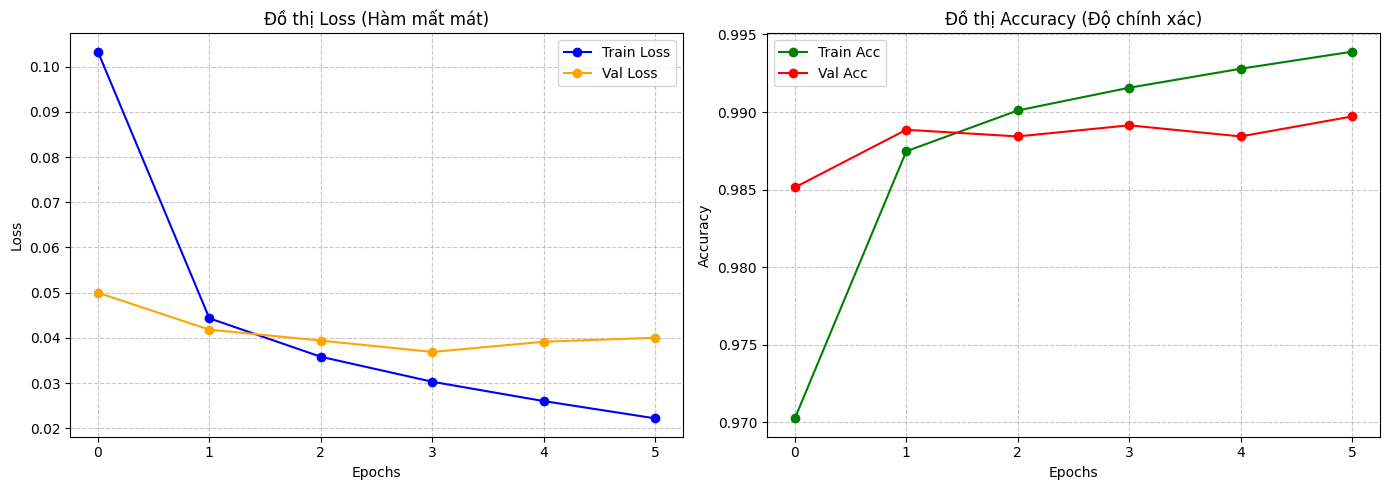


--- LỊCH SỬ HUẤN LUYỆN ---
Epoch 1/10 | Thời gian: 193.7s | Train Loss: 0.1033 | Val Loss: 0.0500 | Val Acc: 0.9851 🌟 [Đã lưu Best Model]
Epoch 2/10 | Thời gian: 199.3s | Train Loss: 0.0443 | Val Loss: 0.0418 | Val Acc: 0.9889 🌟 [Đã lưu Best Model]
Epoch 3/10 | Thời gian: 199.4s | Train Loss: 0.0358 | Val Loss: 0.0394 | Val Acc: 0.9884 🌟 [Đã lưu Best Model]
Epoch 4/10 | Thời gian: 199.9s | Train Loss: 0.0303 | Val Loss: 0.0369 | Val Acc: 0.9891 🌟 [Đã lưu Best Model]
Epoch 5/10 | Thời gian: 201.6s | Train Loss: 0.0260 | Val Loss: 0.0391 | Val Acc: 0.9884 ⚠️ [Cảnh báo: Val Loss không giảm 1/2]
Epoch 6/10 | Thời gian: 200.5s | Train Loss: 0.0222 | Val Loss: 0.0400 | Val Acc: 0.9897 ⚠️ [Cảnh báo: Val Loss không giảm 2/2]

🛑 KÍCH HOẠT EARLY STOPPING: Dừng huấn luyện sớm để chống Overfitting!

Đang tải lại trọng số mô hình tốt nhất để kiểm thử trên tập Test...

BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT):
              precision    recall  f1-score   support

           0       0.96 

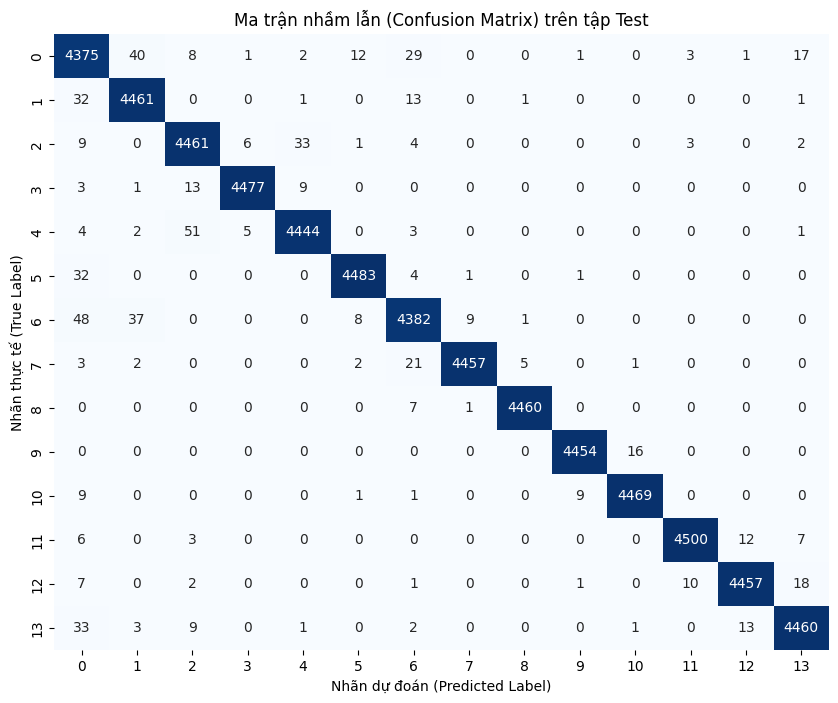

In [7]:
import time
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import clear_output

def calculate_accuracy(logits, labels):
    preds = torch.argmax(logits, dim=1)
    return (preds == labels).float().mean().item()

print("7. Bắt đầu quá trình huấn luyện với Live Plotting & Early Stopping...")

# Các biến theo dõi
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
log_history = [] # <--- Danh sách lưu trữ toàn bộ lịch sử dòng log
best_val_loss = float('inf')
model_save_path = "best_rnn_model.pth"
patience = 2
epochs_no_improve = 0

for epoch in range(1, CONFIG["epochs"] + 1):
    start_time = time.time()

    # ==========================
    # 1. QUÁ TRÌNH TRAINING
    # ==========================
    model.train()
    train_loss, train_acc = 0.0, 0.0
    for token_ids, attn_mask, labels in train_loader:
        token_ids, attn_mask, labels = token_ids.to(device), attn_mask.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(token_ids, attn_mask)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(labels)
        train_acc += calculate_accuracy(logits, labels) * len(labels)

    train_loss /= len(processed_datasets["train"])
    train_acc /= len(processed_datasets["train"])

    # ==========================
    # 2. QUÁ TRÌNH VALIDATION
    # ==========================
    model.eval()
    val_loss, val_acc = 0.0, 0.0
    with torch.no_grad():
        for token_ids, attn_mask, labels in val_loader:
            token_ids, attn_mask, labels = token_ids.to(device), attn_mask.to(device), labels.to(device)
            logits = model(token_ids, attn_mask)
            loss = criterion(logits, labels)

            val_loss += loss.item() * len(labels)
            val_acc += calculate_accuracy(logits, labels) * len(labels)

    val_loss /= len(processed_datasets["val"])
    val_acc /= len(processed_datasets["val"])

    # ==========================
    # 3. CẬP NHẬT LỊCH SỬ & LOG
    # ==========================
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    elapsed = time.time() - start_time

    # Tạo câu log cho epoch hiện tại và đưa vào danh sách
    current_log = f"Epoch {epoch}/{CONFIG['epochs']} | Thời gian: {elapsed:.1f}s | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"

    # Kiểm tra Early Stopping & Lưu Model để nối thêm vào log nếu có
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), model_save_path)
        current_log += f" 🌟 [Đã lưu Best Model]"
    else:
        epochs_no_improve += 1
        current_log += f" ⚠️ [Cảnh báo: Val Loss không giảm {epochs_no_improve}/{patience}]"

    log_history.append(current_log)

    # ==========================
    # 4. VẼ BIỂU ĐỒ REALTIME (LIVE PLOT)
    # ==========================
    clear_output(wait=True) # Xóa khung hình cũ

    plt.figure(figsize=(14, 5))

    # Biểu đồ Loss
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', marker='o', color='blue')
    plt.plot(history['val_loss'], label='Val Loss', marker='o', color='orange')
    plt.title('Đồ thị Loss (Hàm mất mát)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # Biểu đồ Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc', marker='o', color='green')
    plt.plot(history['val_acc'], label='Val Acc', marker='o', color='red')
    plt.title('Đồ thị Accuracy (Độ chính xác)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show() # Vẽ biểu đồ mới

    # In lại toàn bộ lịch sử log nằm ngay dưới biểu đồ
    print("\n--- LỊCH SỬ HUẤN LUYỆN ---")
    for log_msg in log_history:
        print(log_msg)

    # Kích hoạt chốt chặn dừng sớm
    if epochs_no_improve >= patience:
        print("\n🛑 KÍCH HOẠT EARLY STOPPING: Dừng huấn luyện sớm để chống Overfitting!")
        break

# ==========================================
# 5. ĐÁNH GIÁ TẬP TEST VÀ PHÂN TÍCH LỖI
# ==========================================
print("\n" + "="*50)
print("Đang tải lại trọng số mô hình tốt nhất để kiểm thử trên tập Test...")
model.load_state_dict(torch.load(model_save_path, map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for token_ids, attn_mask, labels in test_loader:
        token_ids, attn_mask = token_ids.to(device), attn_mask.to(device)
        logits = model(token_ids, attn_mask)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# In Báo cáo phân loại chi tiết
print("\nBÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT):")
print(classification_report(all_labels, all_preds))

# Vẽ Ma trận nhầm lẫn (Confusion Matrix)
print("\nĐang vẽ Ma trận nhầm lẫn (Confusion Matrix)...")
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Ma trận nhầm lẫn (Confusion Matrix) trên tập Test')
plt.ylabel('Nhãn thực tế (True Label)')
plt.xlabel('Nhãn dự đoán (Predicted Label)')
plt.show()